In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [5]:
df = pd.read_csv("Fitbit_dataset.csv")
df.head()

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


In [3]:
df.shape

(14102, 19)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14102 entries, 0 to 14101
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     14102 non-null  int64  
 1   Age                            14102 non-null  int64  
 2   Gender                         14102 non-null  str    
 3   Weight (kg)                    14102 non-null  float64
 4   Height (m)                     14102 non-null  float64
 5   Max_BPM                        14102 non-null  float64
 6   Avg_BPM                        14102 non-null  float64
 7   Resting_BPM                    14102 non-null  float64
 8   Session_Duration (hours)       14102 non-null  float64
 9   Workout_Type                   14102 non-null  str    
 10  Fat_Percentage                 14102 non-null  float64
 11  Water_Intake (liters)          14102 non-null  float64
 12  Workout_Frequency (days/week)  14102 non-null  int64  
 1

In [5]:
df.describe()

,Unnamed: 0,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
count,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000,14102.000000
mean,7050.500000,38.528365,68.252922,1.680338,181.400794,147.955538,69.333073,0.830135,21.844313,3.598624,4.150262,1.150546,24.092838,6.726918,0.701554,4.924756,279.492866
std,4071.041083,12.007994,13.330332,0.097543,12.913603,14.628858,7.110206,0.288531,5.974424,0.626391,1.650013,1.057974,3.776271,2.180444,0.100263,2.124242,172.858430
min,0.000000,18.000000,37.800000,1.450000,150.000000,109.000000,55.000000,0.250000,8.000000,1.500000,2.000000,0.000000,18.000000,3.000000,0.539474,1.618421,18.400000
25%,3525.250000,28.000000,58.400000,1.610000,171.000000,137.000000,64.000000,0.620000,17.700000,3.200000,3.000000,0.000000,21.200000,6.000000,0.648000,4.187500,143.200000
50%,7050.500000,39.000000,67.300000,1.680000,181.000000,147.000000,70.000000,0.820000,22.000000,3.600000,4.000000,1.000000,24.000000,7.000000,0.700000,4.550000,251.050000
75%,10575.750000,49.000000,77.000000,1.750000,192.000000,158.000000,75.000000,1.030000,26.100000,4.000000,5.000000,2.000000,26.700000,8.000000,0.752475,6.019802,373.700000
max,14101.000000,59.000000,125.100000,1.900000,205.000000,187.000000,85.000000,1.900000,40.000000,5.900000,7.000000,3.000000,35.000000,9.500000,0.860215,8.172043,1442.400000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

Unnamed: 0                       0
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
Base_MET                         0
HR_Intensity                     0
Effective_MET                    0
Calories_Burned (kcal)           0
dtype: int64

In [8]:
df1=df.copy()
df1.drop("Unnamed: 0", axis=1, inplace=True)

In [9]:
numerical_columns = df1.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df1.select_dtypes(include=["str"]).columns

In [10]:
label_encoder=LabelEncoder()
df1["Gender"]=label_encoder.fit_transform(df1["Gender"])

In [11]:
df1["Workout_Type"].unique()

<ArrowStringArray>
['HIIT', 'Yoga', 'Cardio', 'Mixed', 'Strength']
Length: 5, dtype: str

In [12]:
df1= pd.get_dummies(df1,columns=["Workout_Type"],drop_first=True,dtype=int)
df1.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),...,Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal),Workout_Type_HIIT,Workout_Type_Mixed,Workout_Type_Strength,Workout_Type_Yoga
0,56,0,53.8,1.62,163.0,149.0,71.0,1.01,22.1,3.5,...,1,20.4,9.5,0.847826,8.054348,437.7,1,0,0,0
1,46,1,54.9,1.75,170.0,126.0,73.0,0.25,19.9,3.4,...,0,18.0,3.0,0.546392,1.639175,22.5,0,0,0,1
2,32,0,68.5,1.61,190.0,171.0,60.0,0.33,20.4,2.7,...,1,26.5,9.5,0.853846,8.111538,183.4,1,0,0,0
3,25,1,98.8,1.86,189.0,135.0,69.0,0.78,30.3,4.4,...,0,28.5,3.0,0.550000,1.650000,127.2,0,0,0,1
4,38,1,95.5,1.71,176.0,138.0,66.0,0.55,23.7,2.2,...,0,32.5,7.0,0.654545,4.581818,240.7,0,0,0,0


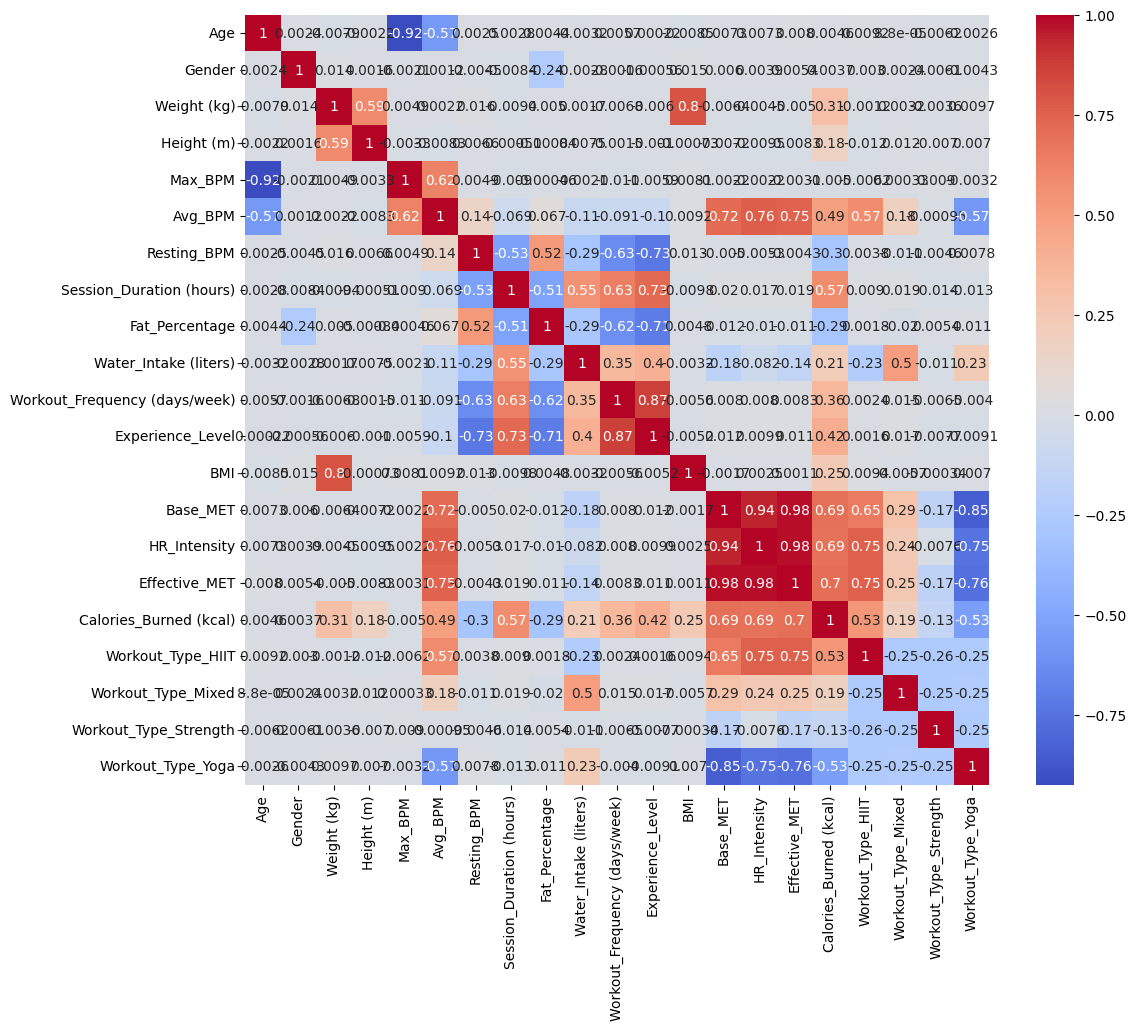

In [13]:
corr = df1.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.show()

In [14]:
corr["Calories_Burned (kcal)"].sort_values(ascending=False)

Calories_Burned (kcal)           1.000000
Effective_MET                    0.704388
Base_MET                         0.692492
HR_Intensity                     0.687703
Session_Duration (hours)         0.573267
Workout_Type_HIIT                0.529710
Avg_BPM                          0.487559
Experience_Level                 0.415616
Workout_Frequency (days/week)    0.360209
Weight (kg)                      0.305190
BMI                              0.248091
Water_Intake (liters)            0.211870
Workout_Type_Mixed               0.187313
Height (m)                       0.177545
Age                              0.004587
Gender                           0.003716
Max_BPM                         -0.004969
Workout_Type_Strength           -0.128805
Fat_Percentage                  -0.293446
Resting_BPM                     -0.295764
Workout_Type_Yoga               -0.533739
Name: Calories_Burned (kcal), dtype: float64

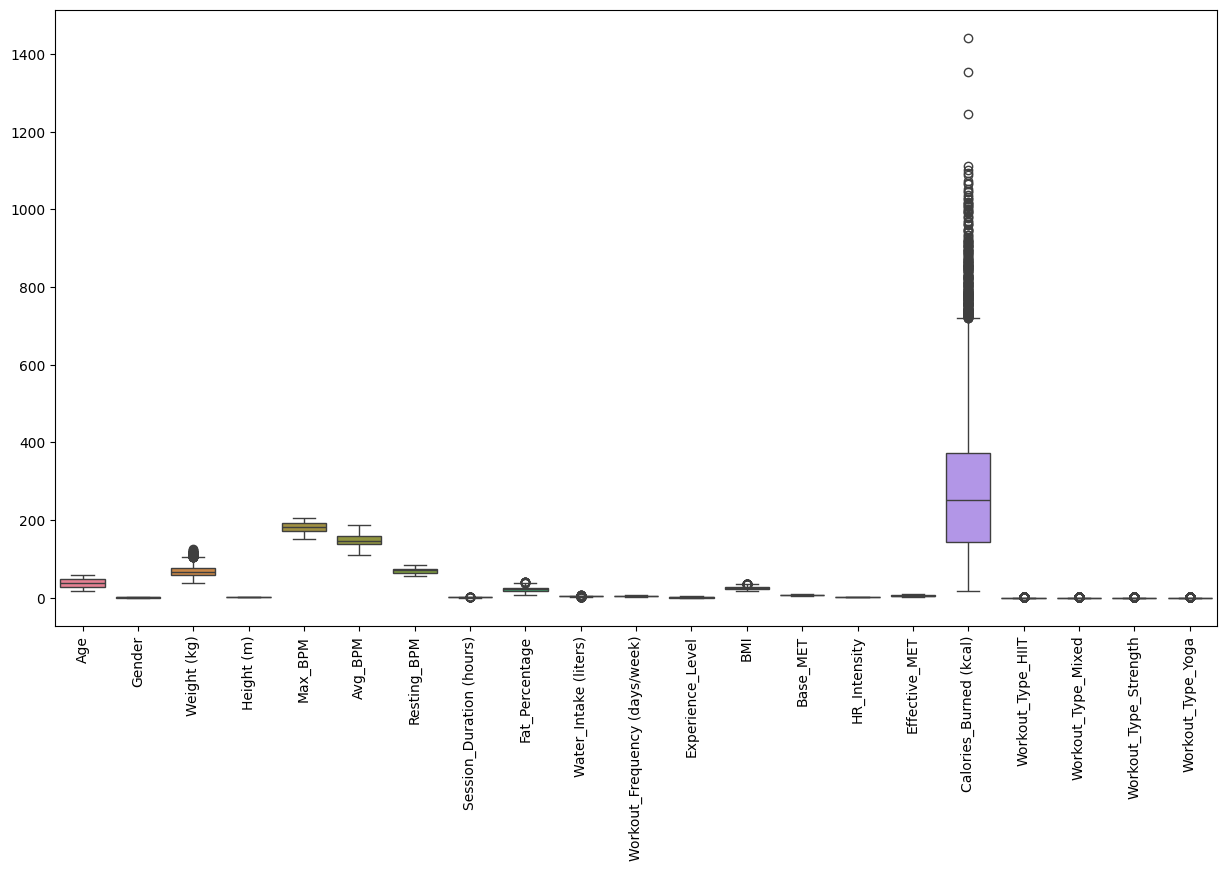

In [15]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df1)
plt.xticks(rotation=90)
plt.show()

In [16]:
def cap_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return column.clip(lower, upper)

for col in numerical_columns:
    df1[col] = cap_outliers(df1[col])

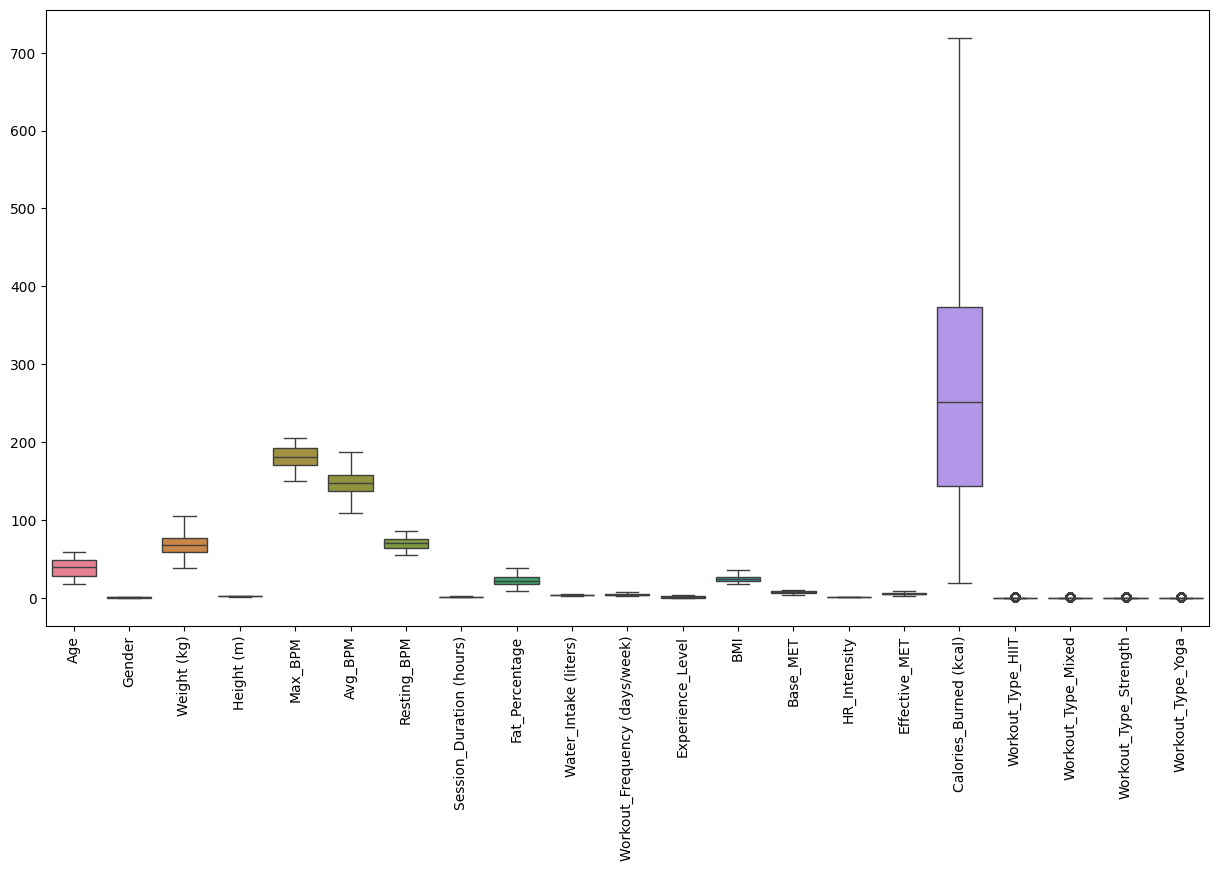

In [17]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df1)
plt.xticks(rotation=90)
plt.show()

In [18]:
X = df1.drop("Calories_Burned (kcal)",axis=1)
y = df1["Calories_Burned (kcal)"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
#Supervised Learning
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def reg_model(model, X_train, y_train, X_test, y_test, name="Model"):

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(name)
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

    return [name, mae, rmse, r2]

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

results = []
results.append(reg_model(LinearRegression(), X_train_scaled, y_train, X_test_scaled, y_test,
                         "Linear Regression"))

results.append(reg_model(Ridge(alpha=1.0), X_train_scaled, y_train, X_test_scaled, y_test,
                         "Ridge Regression"))

results.append(reg_model(Lasso(alpha=0.1), X_train_scaled, y_train, X_test_scaled, y_test,
                         "Lasso Regression"))

results.append(reg_model(KNeighborsRegressor(n_neighbors=5), X_train_scaled, y_train,
                         X_test_scaled, y_test, "KNN Regressor"))

results.append(reg_model(SVR(kernel='rbf'), X_train_scaled, y_train, X_test_scaled, y_test,
                         "Support Vector Regressor"))


Linear Regression
MAE  : 31.76
RMSE : 45.72
R²   : 0.9263
Ridge Regression
MAE  : 31.76
RMSE : 45.72
R²   : 0.9262
Lasso Regression
MAE  : 31.72
RMSE : 45.70
R²   : 0.9263
KNN Regressor
MAE  : 28.25
RMSE : 39.29
R²   : 0.9455
Support Vector Regressor
MAE  : 28.03
RMSE : 48.24
R²   : 0.9179


In [23]:
#without scaling
results.append(reg_model(DecisionTreeRegressor(random_state=42), X_train, y_train,X_test, y_test,
                         "Decision Tree"))

results.append(reg_model(RandomForestRegressor(random_state=42),X_train, y_train,X_test, y_test,
                         "Random Forest"))

results.append(reg_model(XGBRegressor(random_state=42),X_train, y_train,X_test, y_test,
                         "XGBoost"))

Decision Tree
MAE  : 7.55
RMSE : 11.75
R²   : 0.9951
Random Forest
MAE  : 3.63
RMSE : 7.06
R²   : 0.9982
XGBoost
MAE  : 5.15
RMSE : 7.85
R²   : 0.9978


In [24]:
comparison = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
comparison.sort_values(by="R2 Score",ascending=False,inplace=True,ignore_index=True)

comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest,3.630516,7.057925,0.998243
1,XGBoost,5.145729,7.846311,0.997828
2,Decision Tree,7.550798,11.746892,0.995132
3,KNN Regressor,28.248259,39.290657,0.945538
4,Lasso Regression,31.722781,45.697584,0.926328
5,Linear Regression,31.761451,45.718677,0.926260
6,Ridge Regression,31.760332,45.722770,0.926246
7,Support Vector Regressor,28.034310,48.240681,0.917900


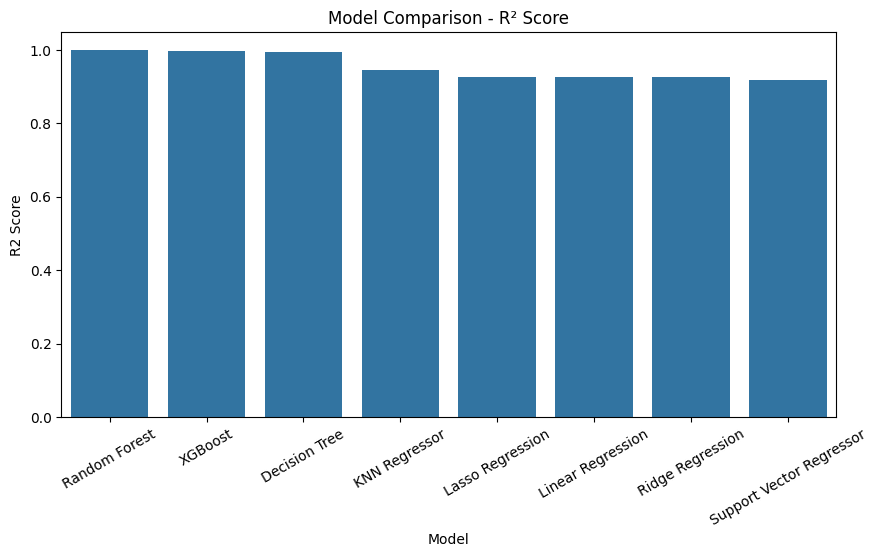

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(data=comparison,x="Model",y="R2 Score")
plt.xticks(rotation=30)
plt.title("Model Comparison - R² Score")
plt.show()

In [6]:
#Unsupervised Learning
cluster_df=df.drop(["Workout_Type","Unnamed: 0"],axis=1)
cluster_df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


In [7]:
#Encoding
label_encoder=LabelEncoder()
cluster_df["Gender"]=label_encoder.fit_transform(cluster_df["Gender"])

In [8]:
#Scaling
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

In [9]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

pca = PCA(n_components=2)
cluster_pca = pca.fit_transform(cluster_scaled)
print(pca.explained_variance_ratio_)

[0.25657577 0.23127937]


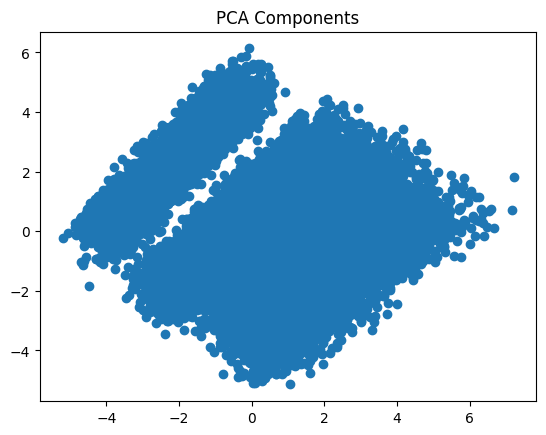

In [10]:
plt.scatter(cluster_pca[:,0],cluster_pca[:,1])
plt.title("PCA Components")
plt.show()

In [11]:
cluster_center = []
for i in range(2,11):
    kmeans = KMeans(n_clusters=i,random_state=42,n_init=10)
    kmeans.fit(cluster_pca)
    cluster_center.append(kmeans.inertia_)

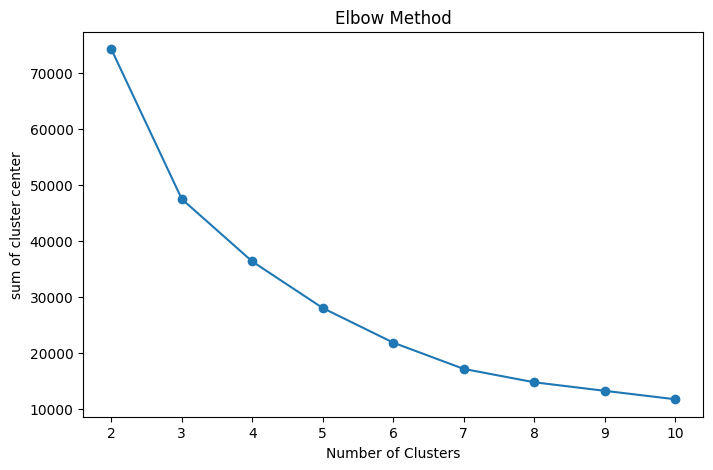

In [12]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11),cluster_center, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("sum of cluster center")
plt.title("Elbow Method")
plt.show()

In [13]:
kmeans = KMeans(n_clusters=6,random_state=42,n_init=10)
clusters = kmeans.fit_predict(cluster_pca)
cluster_df["Cluster"] = clusters

In [20]:
print(kmeans.cluster_centers_)

[[ 3.5682262   0.2003071 ]
 [ 1.13477861  1.49312463]
 [-1.15494857 -1.02713891]
 [ 1.00183467 -2.59823832]
 [-1.17461915  3.60999987]
 [-3.2371846   0.90215323]]


In [14]:
score = silhouette_score(cluster_pca,clusters)
print(score)

0.40573047740491086


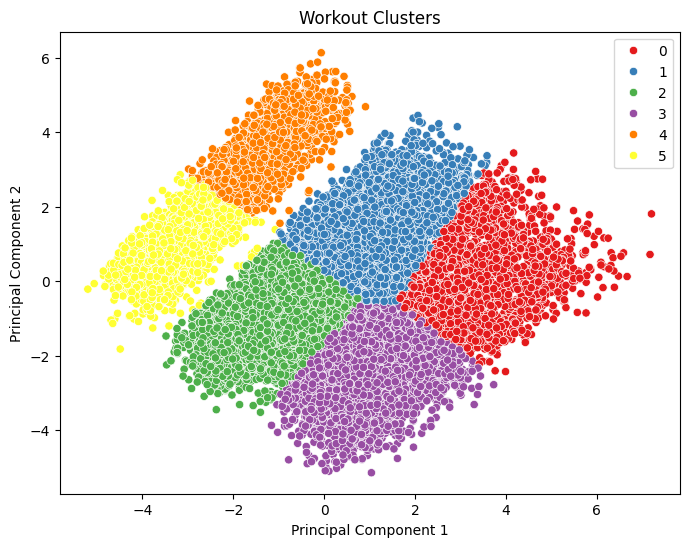

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=cluster_pca[:,0],y=cluster_pca[:,1],hue=clusters,palette="Set1")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Workout Clusters")
plt.show()

In [21]:
cluster_summary = cluster_df.groupby("Cluster").mean(numeric_only=True)
print(cluster_summary)

               Age    Gender  Weight (kg)  Height (m)     Max_BPM     Avg_BPM  \
Cluster                                                                         
0        36.174419  0.531824    70.534455    1.687154  184.157283  161.744186   
1        40.763916  0.526195    67.526948    1.678841  178.790766  143.874591   
2        39.276144  0.491597    67.415686    1.677094  180.725724  147.402428   
3        35.812900  0.489107    68.976890    1.682456  184.427168  164.949594   
4        39.371152  0.544415    68.436939    1.681196  180.288478  127.842568   
5        38.052663  0.469734    68.356901    1.681180  181.726998  133.056901   

         Resting_BPM  Session_Duration (hours)  Fat_Percentage  \
Cluster                                                          
0          63.162791                  1.120894       16.764321   
1          64.090373                  1.047620       17.516405   
2          73.294118                  0.648982       25.136531   
3          73.123452 

In [22]:
cluster_df.groupby("Cluster").mean(numeric_only=True)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
Cluster,,,,,,,,,,,,,,,,,
0,36.174419,0.531824,70.534455,1.687154,184.157283,161.744186,63.162791,1.120894,16.764321,3.951040,5.850061,2.337209,24.706977,8.999082,0.816684,7.383667,577.060404
1,40.763916,0.526195,67.526948,1.678841,178.790766,143.874591,64.090373,1.047620,17.516405,3.832973,5.554355,2.106418,23.895580,6.898985,0.696676,4.819901,337.139424
2,39.276144,0.491597,67.415686,1.677094,180.725724,147.402428,73.294118,0.648982,25.136531,3.262908,3.062558,0.403828,23.874486,6.822596,0.690740,4.721722,204.649393
3,35.812900,0.489107,68.976890,1.682456,184.427168,164.949594,73.123452,0.685835,24.847287,3.325844,3.142247,0.466894,24.294276,9.153353,0.827016,7.596622,355.569329
4,39.371152,0.544415,68.436939,1.681196,180.288478,127.842568,63.667546,1.060193,17.233421,4.185048,5.693052,2.184697,24.145471,3.014072,0.550422,1.660932,120.189622
5,38.052663,0.469734,68.356901,1.681180,181.726998,133.056901,73.384383,0.656398,25.250424,3.670339,3.060533,0.403148,24.094613,3.030266,0.550972,1.673116,74.519673


In [17]:
Experience_cluster = cluster_df.groupby(["Cluster","Experience_Level"]).size().unstack(fill_value=0)
print(Experience_cluster)

Experience_Level     0     1     2    3
Cluster                                
0                    0   161   761  712
1                    0   635  1459  960
2                 2613  1612    59    0
3                 1307   975    59    0
4                    0   193   541  403
5                  995   648     9    0


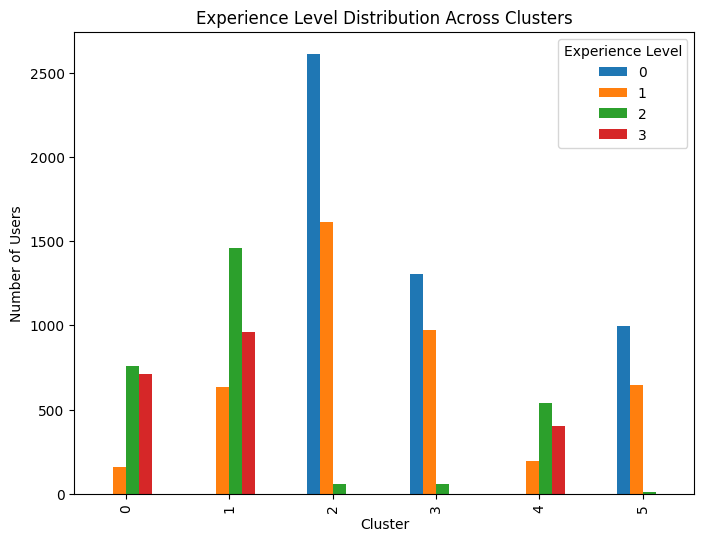

In [18]:
Experience_cluster.plot(kind="bar",figsize=(8,6))

plt.title("Experience Level Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Users")
plt.legend(title="Experience Level")
plt.show()

In [39]:
#Hyperparmeter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
param_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [40]:
print("Best Parameters")
print(grid_rf.best_params_)
print("Best CV Score :",grid_rf.best_score_)
best_rf = grid_rf.best_estimator_
y_pred = best_rf.predict(X_test)

Best Parameters
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score : 0.9977310240271589


In [43]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False,
    ignore_index=True
)

importance.head(10)

,Feature,Importance
0,Session_Duration (hours),0.362713
1,HR_Intensity,0.335643
2,Effective_MET,0.147660
3,Weight (kg),0.120225
4,Base_MET,0.018412
5,Workout_Type_Mixed,0.006958
6,Workout_Type_HIIT,0.003984
7,Workout_Type_Yoga,0.002327
8,Water_Intake (liters),0.000347
9,BMI,0.000306


In [ ]:
import joblib

joblib.dump(best_rf,"best_random_forest.pkl")
joblib.dump(scaler,"scaler.pkl")
joblib.dump(pca,"pca.pkl")
joblib.dump(kmeans,"kmeans.pkl")

: 